In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.visualization import ImageNormalize, LogStretch
from astropy import units as u  
import matplotlib.colors as colors
import astropy.io.fits as pyfits

/var/folders/74/9yc0dt9d53z15d2qpmgpxv4h0000gn/T/ipykernel_70277/1526040959.py:59: RuntimeWarning: invalid value encountered in log10
  im1 = ax[i, 0].imshow(np.log10(kernel), cmap = 'coolwarm')
/var/folders/74/9yc0dt9d53z15d2qpmgpxv4h0000gn/T/ipykernel_70277/1526040959.py:67: RuntimeWarning: divide by zero encountered in log10
  im3 = ax[i, 2].imshow(np.log10(masked_var), cmap='seismic')


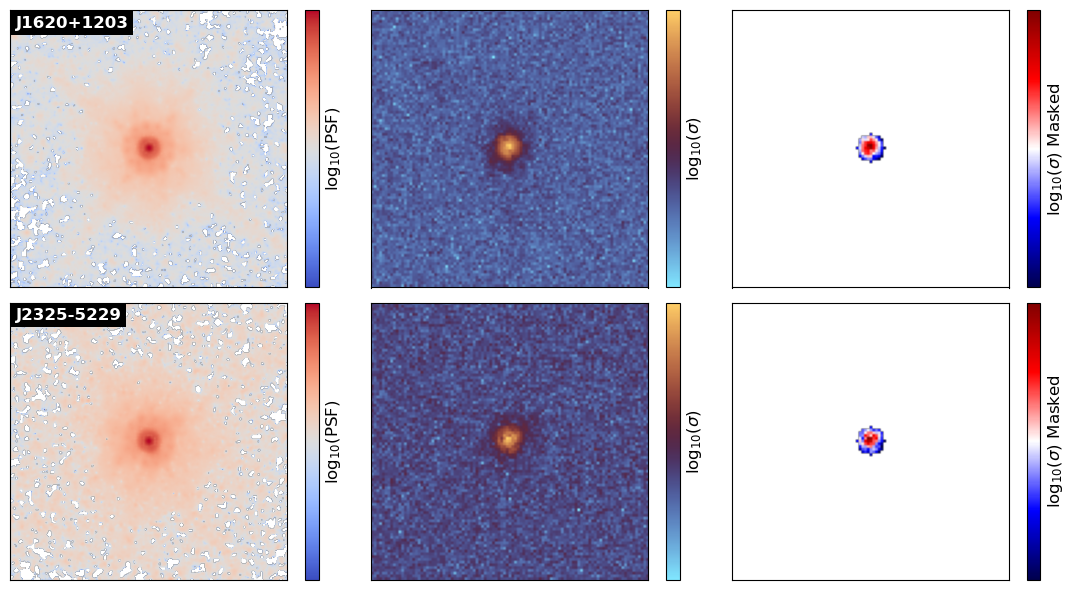

In [2]:
filt = 'F814W'
names = ["J1620+1203", "J2325-5229"]

fig, ax = plt.subplots(2,3, figsize=(11, 6))

fontsize = 12

def mask_psf_variance(var_array, pixel_scale, radius_arcsec=0.1, plot=True):
    """
    Mask a PSF variance map to only include the central region within radius_arcsec.
    Outside the mask, variance is set to zero.
    
    Parameters
    ----------
    var_array : 2D np.ndarray
        Variance map of the PSF
    pixel_scale : float
        Pixel scale in arcsec/pixel (e.g., 0.04 for HST WFC3/UVIS).
    radius_arcsec : float, optional
        Radius (arcsec) of the circular region to keep. Default = 0.1 arcsec.
    plot : bool, optional
        If True, plot the masked variance map. Default = False.

    Returns
    -------
    masked_var : 2D np.ndarray
        Masked variance map (same shape as input, zeros outside mask).
    mask : 2D np.ndarray (bool)
        Boolean mask of the central region.
    """
    radius_pix = radius_arcsec / pixel_scale
    ny, nx = var_array.shape
    y, x = np.indices((ny, nx))
    cy, cx = ny // 2, nx // 2   # assume PSF centered
    r = np.sqrt((x - cx)**2 + (y - cy)**2)

    mask = r <= radius_pix
    masked_var = var_array * mask  # zero outside

    if plot:
        plt.figure(figsize=(6,5))
        plt.imshow(np.log10(masked_var + 1e-12), origin='lower', cmap='magma')
        plt.colorbar(label='log10 variance')
        plt.title(f'Masked PSF Variance Map (radius={radius_arcsec}\" ≈ {radius_pix:.1f} px)')
        plt.show()

    return masked_var, mask

for i, name in enumerate(names):

    psf_file = f'../../cutout_data/{name}/{filt}/outputs/full_PSF.fits'
    kernel = pyfits.getdata(psf_file)

    error_map = np.loadtxt(f'../../cutout_data/{name}/{filt}/psf_variance.txt')
    var_array = np.array(error_map)

    masked_var, _ = mask_psf_variance(var_array, pixel_scale = 0.04, radius_arcsec = 0.2, plot=False)

    im1 = ax[i, 0].imshow(np.log10(kernel), cmap = 'coolwarm')
    cbar1 = fig.colorbar(im1, ax=ax[i,0])
    cbar1.set_label(label=r'log$_{10}$(PSF)', fontsize=fontsize)

    im2 = ax[i, 1].imshow(np.log10(var_array), cmap='managua_r')
    cbar2 = fig.colorbar(im2, ax=ax[i,1], label=r'log$_{10}$($\sigma$)')
    cbar2.set_label(label=r'log$_{10}$($\sigma$)', fontsize=fontsize)

    im3 = ax[i, 2].imshow(np.log10(masked_var), cmap='seismic')
    cbar3 = fig.colorbar(im3, ax=ax[i,2])
    cbar3.set_label(label=r'log$_{10}$($\sigma$) Masked', fontsize=fontsize)

    cbar1.set_ticks([])
    cbar2.set_ticks([])
    cbar3.set_ticks([])

    ax[i, 0].set_xticks([])
    ax[i, 0].set_yticks([])

    ax[i, 1].set_xticks([])
    ax[i, 1].set_yticks([])

    ax[i, 2].set_xticks([])
    ax[i, 2].set_yticks([])

    ax[i, 0].text(
        0.02, 0.98, name,
        transform=ax[i, 0].transAxes,
        fontsize=fontsize,
        color='white',
        fontweight='bold',
        va='top',
        ha='left',
        bbox=dict(facecolor='black', alpha=1., edgecolor='none', pad=3)
    )

plt.tight_layout()

#plt.savefig('psfs.png')